Documents loaded: 91
8.2. TUBE AND TUBE FITTINGS
577
What a gap gauge will not indicate is over-tightening. Over-tightening of a compression ﬁtting
is just as bad as under-tightening, as the ﬁtting cannot form a robust seal once the ferrule and tube
have been deformed. An example of an over-tightened Swagelok two-piece ferrule (left) on a plastic
tube appears in the following photograph, next to a properly swaged ferrule (right):
Note the lack of a substantial gap between the two ferrule pieces in the over-tightened example.
Note also the steeper cone taper of the over-tightened front ferrule, as a result of being pushed too
deep inside the ﬁtting body.

--- Page 1 ---
Chapter 8
Instrument connections
All instruments connect to their respective processes and to each other by means of pipe, tube, and/or
wires. Improper installation of these connective lines can make the diﬀerence between success or
failure in an installation. Safety is also impacted by improper connections between instr

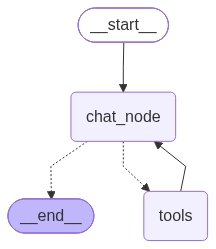

In [ ]:
from typing import Annotated
from typing_extensions import TypedDict

from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS

from langchain_ollama import ChatOllama, OllamaEmbeddings

from langchain_core.tools import tool
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from llmsource import llm

from langchain_community.document_loaders import PyMuPDFLoader

file_path = "chapter8.pdf"

loader = PyMuPDFLoader(file_path)

documents = loader.load()

print("Documents loaded:", len(documents))

print(documents[20].page_content[:1000])

for i in [0, 1, 10, 50, 55, 60]:
    print(f"\n--- Page {i + 1} ---")
    print(documents[i].page_content[:500])

empty_pages = []

for i, doc in enumerate(documents):
    if not doc.page_content.strip():
        empty_pages.append(i + 1)

print("Total pages:", len(documents))
print("Empty pages:", len(empty_pages))
print("Empty page numbers:", empty_pages)

print(type(documents[0]))
print(documents[0].metadata)
print(documents[6].page_content[:500])

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200
)

chunks = text_splitter.split_documents(documents)

print("Pages:", len(documents))
print("Chunks:", len(chunks))

print(chunks[0].page_content)

embeddings = OllamaEmbeddings(
    model="nomic-embed-text"
)

test_vector = embeddings.embed_query(
    "What is a pressure transmitter?"
)

print(type(test_vector))
print("Vector dimensions:", len(test_vector))
print(test_vector[:10])

vector_store = FAISS.from_documents(
    documents=chunks,
    embedding=embeddings
)
print("FAISS database created successfully.")

query = "what is Signal coupling "

results = vector_store.similarity_search(
    query,
    k=3
)

for i, doc in enumerate(results, start=1):
    print(f"\n--- Result {i} ---")
    print("Page:", doc.metadata.get("page"))
    print(doc.page_content[:500])

retriever = vector_store.as_retriever(
    search_kwargs={
        "k": 3
    }
)

retriever.invoke("what is signal coupling")[0].page_content

@tool
def search_pdf(query: str) -> str:
    """
    Search the PDF knowledge base for information relevant
    to the user's question.
    """

    docs = retriever.invoke(query)

    results = []

    for doc in docs:
        page = doc.metadata.get("page", "Unknown")

        results.append(
            f"Page {page + 1}\n"
            f"{doc.page_content}"
        )

    return "\n\n---\n\n".join(results)

from typing import Literal , TypedDict ,Annotated
from langgraph.graph import StateGraph , START, END
from langchain_ollama import ChatOllama
from pydantic import Field, BaseModel
from langgraph.graph.message import BaseMessage , add_messages
from langchain_core.messages import HumanMessage ,AIMessage
from langgraph.checkpoint.memory import MemorySaver
from llmsource import llm
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.tools import tool

model = "qwen3.5:9b"
import numexpr

@tool
def calculator(expression: str) -> str:
    """Evaluate a mathematical expression."""
    try:
        result = numexpr.evaluate(expression)
        return str(result)
    except Exception as e:
        return f"Error: {e}"
    
    
tools = [calculator,search_pdf]
tools_node = ToolNode(tools)
llm_with_tools = llm.bind_tools(tools)



class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage],add_messages]


def chat_node(state:ChatState)->ChatState:
    message = state['messages']
   
    response = llm_with_tools.invoke(message)
    
    return{
        "messages":[response]
    }
checkpoint = MemorySaver()
graph = StateGraph(ChatState)
graph.add_node('chat_node',chat_node)
graph.add_node('tools',tools_node)

graph.add_conditional_edges('chat_node',tools_condition)

# define edges
graph.add_edge(START,'chat_node')
graph.add_edge('tools','chat_node')

# graph.add_edge('chat_node',END)
chatbot = graph.compile(checkpoint)

# memory
config = {
    "configurable": {
        "thread_id": "1"
    }
}



init={"messages": [HumanMessage(content="What is signal coupling")]}

response = chatbot.invoke(init,config)

# print(response['messages'][-1].content)      
for message in response["messages"]:
    print(type(message).__name__)
    print("content:", message.content)

    if hasattr(message, "tool_calls"):
        print("tool_calls:", message.tool_calls)

    print("-" * 50)


HumanMessage
content: What is signal coupling
--------------------------------------------------
AIMessage
content: Signal coupling refers to the transfer of energy or information from one part of a system (like an electrical circuit) to another. This transfer can happen through various mechanisms, primarily categorized into two main types: **capacitive coupling** and **inductive coupling**.

Here is a breakdown of how it works:

*   **Capacitive Coupling:** This occurs when an electric field from one conductor induces a voltage on a nearby conductor. It essentially acts like a capacitor formed between the two conductors. High-frequency signals are more easily coupled this way because capacitors block low frequencies (DC) but pass high frequencies.
*   **Inductive Coupling:** This happens when a changing magnetic field generated by current in one conductor induces a voltage in a nearby conductor. This is the principle behind transformers and wireless charging, but it can also cause unw